# IROA 토큰 이코노미 시뮬레이션

## tl;dr

이 노트북은 승인된 7개 통합 배분안을 대상으로 공급, 잠금 해제, NODE 보상 희석과 매도 압력을 검증한다. 가격 상승이나 거래소 상장은 가정하지 않는다. 핵심 판단은 토큰 보상이 NODE 운영비의 전부가 될 수 없으며, 실제 서비스 수익과 함께 작동해야 한다는 것이다.

## Context & Methods

### Key Assumptions

- 최대 공급량: 100억 IROA, 추가 발행 없음
- 초기 유통량: 전체 공급의 2%
- NODE 보상: 12년 배출, 작업 성공·가동·보안·품질 기반
- 생태계 참여 보상과 연구개발: 10년 분산 집행
- 초기 투자자: 18개월 잠금 후 42개월 선형 해제
- 팀·자문: 24개월 잠금 후 72개월 선형 해제
- 재단 준비금: 12개월 잠금 후 84개월 선형 해제
- 모델은 토큰 수량과 해제 비율을 검증한다. 원화 가치·가격·수익률은 예측하지 않는다.

검토 근거는 승인된 IROA 배분안, 기존 IROA 백서, 금융위원회의 증권성 실질 판단 원칙, 가상자산 이용자 보호법과 FIU 신고 안내다. 법률 분류는 별도 전문 검토가 필요하다.


In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

TOTAL_SUPPLY = 10_000_000_000
ROOT = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'docs/whitepaper').exists()), Path.cwd())
ANALYSIS_DIR = ROOT / 'docs/whitepaper/analysis'
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

allocation_pct = {
    'NODE 구축·운영 보상': 25,
    '생태계 참여 보상': 23,
    '연구개발': 15,
    '팀·자문': 15,
    '초기 투자자': 10,
    '재단·운영 준비금': 7,
    '초기 유동성': 5,
}

allocation = pd.DataFrame(
    [{'배분': name, '비율(%)': pct, '수량': TOTAL_SUPPLY * pct / 100}
     for name, pct in allocation_pct.items()]
)
assert allocation['비율(%)'].sum() == 100
assert allocation['수량'].sum() == TOTAL_SUPPLY
allocation

,배분,비율(%),수량
0,NODE 구축·운영 보상,25,2.500000e+09
1,생태계 참여 보상,23,2.300000e+09
2,연구개발,15,1.500000e+09
3,팀·자문,15,1.500000e+09
4,초기 투자자,10,1.000000e+09
5,재단·운영 준비금,7,7.000000e+08
6,초기 유동성,5,5.000000e+08


## Data

배분 수치는 사용자가 승인한 통합안이다. 아래 해제 곡선은 백서에 넣을 운영 원칙을 검증하기 위한 기준 시나리오이며, 실제 스마트계약 배포 전 법률·보안 검토에서 다시 확인해야 한다.


In [2]:
months = np.arange(0, 145)
schedule = pd.DataFrame(index=months)
schedule.index.name = 'month'
for bucket in allocation_pct:
    schedule[bucket] = 0.0

def spread_year_weights(column, pool_tokens, weights):
    assert sum(weights) == 100
    for year, weight in enumerate(weights, start=1):
        start = (year - 1) * 12 + 1
        end = year * 12
        schedule.loc[start:end, column] = pool_tokens * weight / 100 / 12

def linear_unlock(column, pool_tokens, start_month, duration_months):
    end_month = start_month + duration_months - 1
    schedule.loc[start_month:end_month, column] = pool_tokens / duration_months

# 초기 유동성: TGE 2%, 잔여 3%는 36개월 선형 공급
schedule.loc[0, '초기 유동성'] = TOTAL_SUPPLY * 0.02
schedule.loc[1:36, '초기 유동성'] = TOTAL_SUPPLY * 0.03 / 36

spread_year_weights('NODE 구축·운영 보상', TOTAL_SUPPLY * 0.25,
                    [15, 13, 12, 11, 10, 9, 8, 7, 5, 4, 3, 3])
spread_year_weights('생태계 참여 보상', TOTAL_SUPPLY * 0.23,
                    [12, 12, 11, 11, 10, 10, 9, 9, 8, 8])
spread_year_weights('연구개발', TOTAL_SUPPLY * 0.15,
                    [12, 12, 12, 12, 12, 10, 10, 8, 6, 6])

linear_unlock('초기 투자자', TOTAL_SUPPLY * 0.10, start_month=19, duration_months=42)
linear_unlock('팀·자문', TOTAL_SUPPLY * 0.15, start_month=25, duration_months=72)
linear_unlock('재단·운영 준비금', TOTAL_SUPPLY * 0.07, start_month=13, duration_months=84)

schedule['월 신규 유통량'] = schedule[list(allocation_pct)].sum(axis=1)
schedule['누적 유통량'] = schedule['월 신규 유통량'].cumsum()
schedule['누적 유통률(%)'] = schedule['누적 유통량'] / TOTAL_SUPPLY * 100
assert math.isclose(schedule['누적 유통량'].iloc[-1], TOTAL_SUPPLY, rel_tol=0, abs_tol=1e-4)

annual_rows = []
for year in range(0, 13):
    month = year * 12
    start = 0 if year == 0 else (year - 1) * 12 + 1
    annual_rows.append({
        '연도': year,
        '연말 누적 유통량': schedule.loc[month, '누적 유통량'],
        '연말 유통률(%)': schedule.loc[month, '누적 유통률(%)'],
        '해당 연도 신규 유통량': schedule.loc[start:month, '월 신규 유통량'].sum(),
    })
annual = pd.DataFrame(annual_rows)
annual

,연도,연말 누적 유통량,연말 유통률(%),해당 연도 신규 유통량
0,0,2.000000e+08,2.000000,2.000000e+08
1,1,1.131000e+09,11.310000,9.310000e+08
2,2,2.254857e+09,22.548571,1.123857e+09
3,3,3.723571e+09,37.235714,1.468714e+09
4,4,5.067286e+09,50.672857,1.343714e+09
5,5,6.363000e+09,63.630000,1.295714e+09
6,6,7.318000e+09,73.180000,9.550000e+08
7,7,8.225000e+09,82.250000,9.070000e+08
8,8,9.077000e+09,90.770000,8.520000e+08
9,9,9.476000e+09,94.760000,3.990000e+08


## Results

### 배분 구조와 유통량

구성비는 정확한 비교가 중요하므로 가로 막대그래프로 표시한다. 유통량은 초기 2%에서 시작해 보상과 잠금 해제가 분산되도록 설계했다.


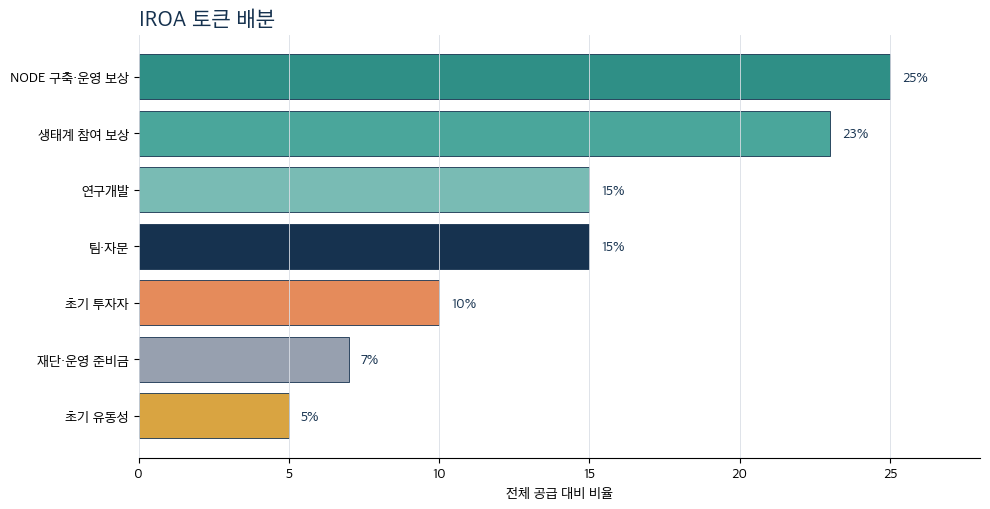

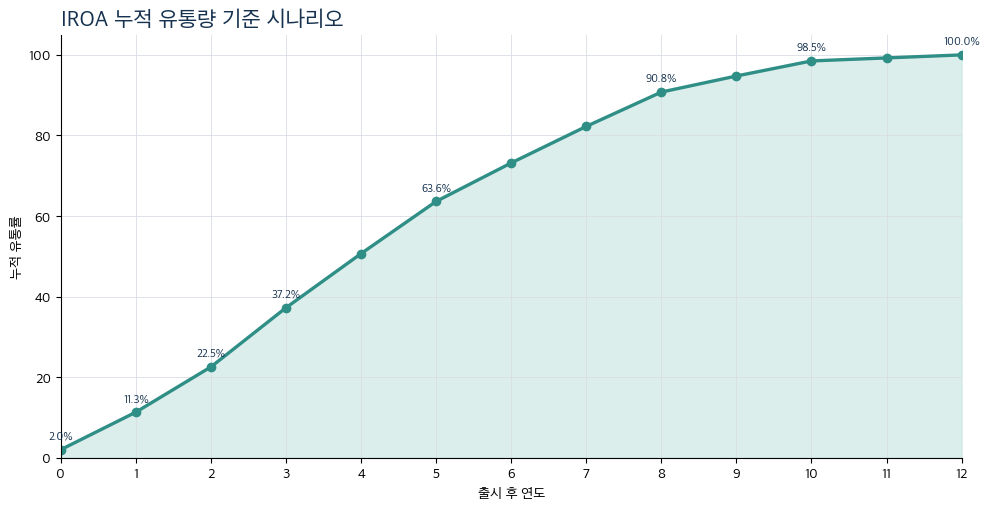

In [3]:
plt.rcParams['font.family'] = ['Apple SD Gothic Neo', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
colors = ['#2F8F86', '#4AA69B', '#79BBB4', '#16324F', '#E58B5B', '#97A0AF', '#D9A441']

fig, ax = plt.subplots(figsize=(10, 5.2))
plot_alloc = allocation.iloc[::-1]
ax.barh(plot_alloc['배분'], plot_alloc['비율(%)'], color=colors[::-1], edgecolor='#16324F', linewidth=0.6)
for idx, value in enumerate(plot_alloc['비율(%)']):
    ax.text(value + 0.4, idx, f'{value:.0f}%', va='center', fontsize=10, color='#16324F')
ax.set_xlim(0, 28)
ax.set_xlabel('전체 공급 대비 비율')
ax.set_title('IROA 토큰 배분', loc='left', fontsize=16, fontweight='bold', color='#16324F')
ax.grid(axis='x', color='#D9DEE5', linewidth=0.6)
ax.spines[['top', 'right', 'left']].set_visible(False)
fig.tight_layout()
allocation_chart = ANALYSIS_DIR / 'iroa-token-allocation.png'
fig.savefig(allocation_chart, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(annual['연도'], annual['연말 유통률(%)'], color='#2F8F86', marker='o', linewidth=2.4)
ax.fill_between(annual['연도'], annual['연말 유통률(%)'], color='#BFE0DB', alpha=0.55)
ax.set_xlim(0, 12)
ax.set_ylim(0, 105)
ax.set_xticks(range(0, 13))
ax.set_yticks(range(0, 101, 20))
ax.set_xlabel('출시 후 연도')
ax.set_ylabel('누적 유통률')
ax.set_title('IROA 누적 유통량 기준 시나리오', loc='left', fontsize=16, fontweight='bold', color='#16324F')
ax.grid(color='#D9DEE5', linewidth=0.6)
ax.spines[['top', 'right']].set_visible(False)
for _, row in annual.iloc[[0,1,2,3,5,8,10,12]].iterrows():
    ax.annotate(f"{row['연말 유통률(%)']:.1f}%", (row['연도'], row['연말 유통률(%)']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8, color='#16324F')
fig.tight_layout()
supply_chart = ANALYSIS_DIR / 'iroa-token-circulating-supply.png'
fig.savefig(supply_chart, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

### NODE 보상 희석 스트레스 테스트

NODE 수가 증가할수록 정해진 배출량을 NODE 수로 나눈 단순 평균은 빠르게 감소한다. 이 검증은 토큰 배출만으로 NODE 운영비를 보장할 수 없음을 확인하기 위한 것이다. 실제 보상은 원화 서비스 수수료와 토큰 성과 보상을 함께 사용해야 한다.


,시나리오,연도,활성 NODE,NODE 보상 배출량,NODE당 단순 평균 토큰
0,보수,1,100,375000000.0,3.750000e+06
1,보수,3,400,300000000.0,7.500000e+05
2,보수,5,1000,250000000.0,2.500000e+05
3,보수,8,3000,175000000.0,5.833333e+04
4,보수,10,5000,100000000.0,2.000000e+04
5,보수,12,7000,75000000.0,1.071429e+04
6,기준,1,300,375000000.0,1.250000e+06
7,기준,3,1500,300000000.0,2.000000e+05
8,기준,5,5500,250000000.0,4.545455e+04
9,기준,8,20000,175000000.0,8.750000e+03


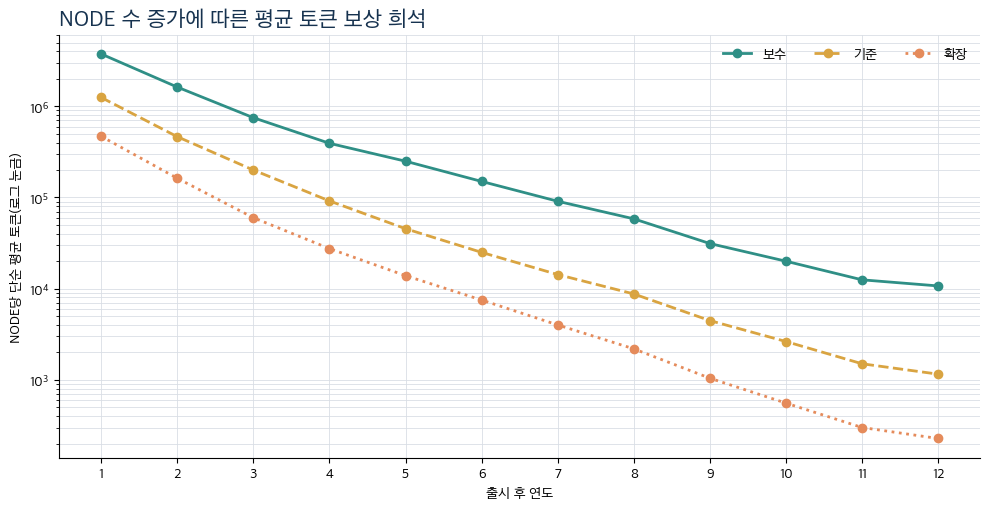

In [4]:
node_year_weights = np.array([15, 13, 12, 11, 10, 9, 8, 7, 5, 4, 3, 3])
node_emission = TOTAL_SUPPLY * 0.25 * node_year_weights / 100
node_counts = {
    '보수': [100, 200, 400, 700, 1_000, 1_500, 2_200, 3_000, 4_000, 5_000, 6_000, 7_000],
    '기준': [300, 700, 1_500, 3_000, 5_500, 9_000, 14_000, 20_000, 28_000, 38_000, 50_000, 65_000],
    '확장': [800, 2_000, 5_000, 10_000, 18_000, 30_000, 50_000, 80_000, 120_000, 180_000, 250_000, 330_000],
}

node_rows = []
for scenario, counts in node_counts.items():
    for year, (nodes, emission) in enumerate(zip(counts, node_emission), start=1):
        node_rows.append({
            '시나리오': scenario,
            '연도': year,
            '활성 NODE': nodes,
            'NODE 보상 배출량': emission,
            'NODE당 단순 평균 토큰': emission / nodes,
        })
node_df = pd.DataFrame(node_rows)
display(node_df[node_df['연도'].isin([1,3,5,8,10,12])].reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 5.2))
line_styles = {'보수': '-', '기준': '--', '확장': ':'}
line_colors = {'보수': '#2F8F86', '기준': '#D9A441', '확장': '#E58B5B'}
for scenario in node_counts:
    subset = node_df[node_df['시나리오'] == scenario]
    ax.plot(subset['연도'], subset['NODE당 단순 평균 토큰'], label=scenario,
            color=line_colors[scenario], linestyle=line_styles[scenario], marker='o', linewidth=2)
ax.set_yscale('log')
ax.set_xticks(range(1, 13))
ax.set_xlabel('출시 후 연도')
ax.set_ylabel('NODE당 단순 평균 토큰(로그 눈금)')
ax.set_title('NODE 수 증가에 따른 평균 토큰 보상 희석', loc='left', fontsize=16, fontweight='bold', color='#16324F')
ax.grid(color='#D9DEE5', linewidth=0.6, which='both')
ax.legend(frameon=False, ncol=3, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
node_chart = ANALYSIS_DIR / 'iroa-node-reward-dilution.png'
fig.savefig(node_chart, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

### 잠금 해제와 내부자 매도 압력

초기 투자자와 팀·자문 물량은 출시 시점에 유통하지 않는다. 잠금 해제를 월별 선형으로 분산해 어느 한 달에 대규모 물량이 몰리는 현상을 줄인다.


In [5]:
prior_circulating = schedule['누적 유통량'].shift(1)
schedule['내부자 월 해제량'] = schedule['초기 투자자'] + schedule['팀·자문']
schedule['내부자 월 해제/직전 유통량(%)'] = np.where(
    prior_circulating > 0,
    schedule['내부자 월 해제량'] / prior_circulating * 100,
    0,
)
max_insider_ratio = schedule.loc[13:, '내부자 월 해제/직전 유통량(%)'].max()
max_insider_month = int(schedule.loc[13:, '내부자 월 해제/직전 유통량(%)'].idxmax())

validation = pd.DataFrame([
    {'검증 항목': '배분 합계', '기준': '100%', '결과': f"{allocation['비율(%)'].sum():.0f}%", '판정': '통과'},
    {'검증 항목': '초기 유통량', '기준': '5% 이하', '결과': f"{schedule.loc[0, '누적 유통률(%)']:.1f}%", '판정': '통과' if schedule.loc[0, '누적 유통률(%)'] <= 5 else '재설계'},
    {'검증 항목': '팀·투자자 초기 유통', '기준': '0%', '결과': f"{(schedule.loc[0, '팀·자문'] + schedule.loc[0, '초기 투자자']) / TOTAL_SUPPLY * 100:.1f}%", '판정': '통과'},
    {'검증 항목': '월 최대 내부자 해제 충격', '기준': '직전 유통량의 2% 이하', '결과': f"{max_insider_ratio:.2f}% (월 {max_insider_month})", '판정': '통과' if max_insider_ratio <= 2 else '재설계'},
    {'검증 항목': 'NODE 보상 기간', '기준': '10년 이상', '결과': '12년', '판정': '통과'},
    {'검증 항목': 'NODE·생태계·연구개발 비중', '기준': '60% 이상', '결과': f"{allocation_pct['NODE 구축·운영 보상'] + allocation_pct['생태계 참여 보상'] + allocation_pct['연구개발']}%", '판정': '통과'},
    {'검증 항목': 'NODE 고정수익 보장', '기준': '금지', '결과': '서비스 수수료 + 성과형 토큰 보상', '판정': '통과'},
])
validation

,검증 항목,기준,결과,판정
0,배분 합계,100%,100%,통과
1,초기 유통량,5% 이하,2.0%,통과
2,팀·투자자 초기 유통,0%,0.0%,통과
3,월 최대 내부자 해제 충격,직전 유통량의 2% 이하,1.98% (월 25),통과
4,NODE 보상 기간,10년 이상,12년,통과
5,NODE·생태계·연구개발 비중,60% 이상,63%,통과
6,NODE 고정수익 보장,금지,서비스 수수료 + 성과형 토큰 보상,통과


In [6]:
base = node_df[node_df['시나리오'] == '기준'].copy()
base_first = base.iloc[0]['NODE당 단순 평균 토큰']
base_last = base.iloc[-1]['NODE당 단순 평균 토큰']
decline_factor = base_first / base_last
year1_circulation = annual.loc[annual['연도'] == 1, '연말 유통률(%)'].iloc[0]
year5_circulation = annual.loc[annual['연도'] == 5, '연말 유통률(%)'].iloc[0]
year10_circulation = annual.loc[annual['연도'] == 10, '연말 유통률(%)'].iloc[0]

headers = list(validation.columns)
validation_lines = [
    '| ' + ' | '.join(headers) + ' |',
    '| ' + ' | '.join(['---'] * len(headers)) + ' |',
]
for _, row in validation.iterrows():
    validation_lines.append('| ' + ' | '.join(str(row[header]) for header in headers) + ' |')
validation_markdown = '\n'.join(validation_lines)

summary_md = f'''# IROA 토큰 이코노미 검증 결과

## 결론

승인된 7개 배분안은 공급 합계, 초기 유통량, 내부자 잠금, 장기 NODE 보상 기간 기준을 충족한다. 다만 토큰 배출만으로 NODE 운영비를 보장하는 구조는 지속 가능하지 않다. NODE 운영자는 실제 서비스 수수료를 기본 수익으로 받고, 토큰은 검증된 작업·가동·보안·품질에 대한 성과 보상으로 받아야 한다.

## 핵심 수치

- 최대 공급량: {TOTAL_SUPPLY:,.0f} IROA
- 초기 유통률: {schedule.loc[0, '누적 유통률(%)']:.1f}%
- 1년 말 누적 유통률: {year1_circulation:.1f}%
- 5년 말 누적 유통률: {year5_circulation:.1f}%
- 10년 말 누적 유통률: {year10_circulation:.1f}%
- 월 최대 팀·투자자 해제 충격: 직전 유통량의 {max_insider_ratio:.2f}%
- NODE 보상 기간: 12년
- 기준 시나리오의 NODE당 단순 평균 토큰 감소: 약 {decline_factor:,.0f}배

## 검증 판정

{validation_markdown}

## 백서 반영 원칙

- NODE 보상은 등록이 아니라 검증된 작업과 품질에 지급한다.
- NODE 운영비는 원화 또는 규제된 결제수단의 서비스 수수료를 기본으로 한다.
- 토큰 보상은 고정가격·고정수익·환매를 약속하지 않는다.
- 서비스 이용자는 토큰 보유 없이도 핵심 서비스를 이용할 수 있다.
- 팀·자문은 24개월 잠금 후 72개월, 초기 투자자는 18개월 잠금 후 42개월에 걸쳐 해제한다.
- 재단과 연구개발 물량은 다중서명, 단계별 예산, 분기 공개와 외부 검토를 적용한다.
- 실제 발행 전 증권성, 가상자산사업자 해당 여부, 세무·회계, 개인정보, 스마트계약 보안을 별도 검토한다.
'''

validation_path = ANALYSIS_DIR / 'IROA_TOKEN_ECONOMY_VALIDATION.md'
validation_path.write_text(summary_md, encoding='utf-8')
display(Markdown(summary_md))

# IROA 토큰 이코노미 검증 결과

## 결론

승인된 7개 배분안은 공급 합계, 초기 유통량, 내부자 잠금, 장기 NODE 보상 기간 기준을 충족한다. 다만 토큰 배출만으로 NODE 운영비를 보장하는 구조는 지속 가능하지 않다. NODE 운영자는 실제 서비스 수수료를 기본 수익으로 받고, 토큰은 검증된 작업·가동·보안·품질에 대한 성과 보상으로 받아야 한다.

## 핵심 수치

- 최대 공급량: 10,000,000,000 IROA
- 초기 유통률: 2.0%
- 1년 말 누적 유통률: 11.3%
- 5년 말 누적 유통률: 63.6%
- 10년 말 누적 유통률: 98.5%
- 월 최대 팀·투자자 해제 충격: 직전 유통량의 1.98%
- NODE 보상 기간: 12년
- 기준 시나리오의 NODE당 단순 평균 토큰 감소: 약 1,083배

## 검증 판정

| 검증 항목 | 기준 | 결과 | 판정 |
| --- | --- | --- | --- |
| 배분 합계 | 100% | 100% | 통과 |
| 초기 유통량 | 5% 이하 | 2.0% | 통과 |
| 팀·투자자 초기 유통 | 0% | 0.0% | 통과 |
| 월 최대 내부자 해제 충격 | 직전 유통량의 2% 이하 | 1.98% (월 25) | 통과 |
| NODE 보상 기간 | 10년 이상 | 12년 | 통과 |
| NODE·생태계·연구개발 비중 | 60% 이상 | 63% | 통과 |
| NODE 고정수익 보장 | 금지 | 서비스 수수료 + 성과형 토큰 보상 | 통과 |

## 백서 반영 원칙

- NODE 보상은 등록이 아니라 검증된 작업과 품질에 지급한다.
- NODE 운영비는 원화 또는 규제된 결제수단의 서비스 수수료를 기본으로 한다.
- 토큰 보상은 고정가격·고정수익·환매를 약속하지 않는다.
- 서비스 이용자는 토큰 보유 없이도 핵심 서비스를 이용할 수 있다.
- 팀·자문은 24개월 잠금 후 72개월, 초기 투자자는 18개월 잠금 후 42개월에 걸쳐 해제한다.
- 재단과 연구개발 물량은 다중서명, 단계별 예산, 분기 공개와 외부 검토를 적용한다.
- 실제 발행 전 증권성, 가상자산사업자 해당 여부, 세무·회계, 개인정보, 스마트계약 보안을 별도 검토한다.


## Takeaways

- 7개 통합 배분안은 합계 100%이며, NODE·생태계·연구개발에 63%를 둔다.
- 초기 유통은 2%이고 팀·자문과 초기 투자자 물량은 출시 시점에 유통하지 않는다.
- NODE 보상 풀은 12년에 걸쳐 배출하지만, NODE 수가 증가하면 NODE당 토큰 수량은 크게 감소한다.
- 따라서 토큰은 NODE 구축을 촉진하는 초기·성과 보상이며, 장기 운영비는 실제 서비스 매출과 계약 수익으로 충당해야 한다.
- 고정가격, 수익률, 환매, 상장을 약속하지 않고 핵심 서비스는 토큰 보유와 분리한다.
